# 08 – Anomaly Detection in Contractor Business Metrics
## Business Context
ServiceTitan monitors hundreds of KPIs per contractor account:
- Daily job volume, revenue, booking rate, cancellation rate
- Call answer rate, average call duration
- Technician utilization, overtime hours
- Payment processing failure rate

Sudden changes in these metrics can indicate:
- Business problems the contractor needs help with (churn precursor)
- Data pipeline issues (bugs in reporting)
- Fraud or billing anomalies
- Competitive disruption in the local market

Goal: **automatically flag metric anomalies for investigation**,
with low enough false positive rate that alerts are actionable.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Simulate multi-account KPI time series ──────────────────────────────────
n_accounts = 50
n_days = 180

def simulate_account_metrics(account_id, inject_anomaly=False):
    """Simulate daily KPIs for one account with optional injected anomaly."""
    dates = pd.date_range('2024-07-01', periods=n_days, freq='D')
    t = np.arange(n_days)
    
    # Base level varies by account
    rng = np.random.default_rng(account_id)
    base_jobs   = rng.uniform(5, 25)
    base_rev    = base_jobs * rng.uniform(250, 450)
    
    # Day of week effect
    dow = np.array([d.dayofweek for d in dates])
    dow_mult = np.array([1.2, 1.1, 1.0, 1.0, 0.9, 0.7, 0.4])[dow]
    
    # Slow trend
    trend = 0.001 * t
    
    jobs_per_day = (base_jobs * dow_mult * (1 + trend)
                    + rng.normal(0, base_jobs * 0.15, n_days)).clip(0)
    revenue_per_day = jobs_per_day * rng.uniform(280, 380, n_days)
    booking_rate = np.clip(0.75 + rng.normal(0, 0.05, n_days), 0.3, 0.99)
    cancel_rate  = np.clip(0.05 + rng.normal(0, 0.02, n_days), 0.0, 0.4)
    
    # Inject anomaly: sudden drop in jobs (e.g., technician quit, equipment issue)
    if inject_anomaly:
        anomaly_start = 140  # 20 days before end of series
        jobs_per_day[anomaly_start:]     *= 0.4  # 60% drop
        revenue_per_day[anomaly_start:]  *= 0.4
        booking_rate[anomaly_start:]     -= 0.25
    
    return pd.DataFrame({
        'date':        dates,
        'account_id':  account_id,
        'jobs':        jobs_per_day.round(1),
        'revenue':     revenue_per_day.round(2),
        'booking_rate': booking_rate.round(3),
        'cancel_rate': cancel_rate.round(3),
        'has_anomaly': inject_anomaly and (t >= 140)
    })

# Generate data for 50 accounts; inject anomalies in 8 of them
anomaly_accounts = set(np.random.choice(n_accounts, 8, replace=False))
dfs = [simulate_account_metrics(i, inject_anomaly=(i in anomaly_accounts))
       for i in range(n_accounts)]
all_data = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(all_data)}")
print(f"Accounts with injected anomalies: {sorted(anomaly_accounts)}")


Total rows: 9000
Accounts with injected anomalies: [np.int64(13), np.int64(17), np.int64(25), np.int64(26), np.int64(30), np.int64(39), np.int64(45), np.int64(48)]


## Anomaly Detection Methods
We implement and compare three approaches:

1. **Z-score (rolling)**: flag if current value is >3 std deviations from rolling mean
2. **Percentage change**: flag if week-over-week change exceeds a threshold
3. **Isolation Forest**: unsupervised ML approach, works well on multi-dimensional data

In production, all three can run in parallel with different sensitivity thresholds.


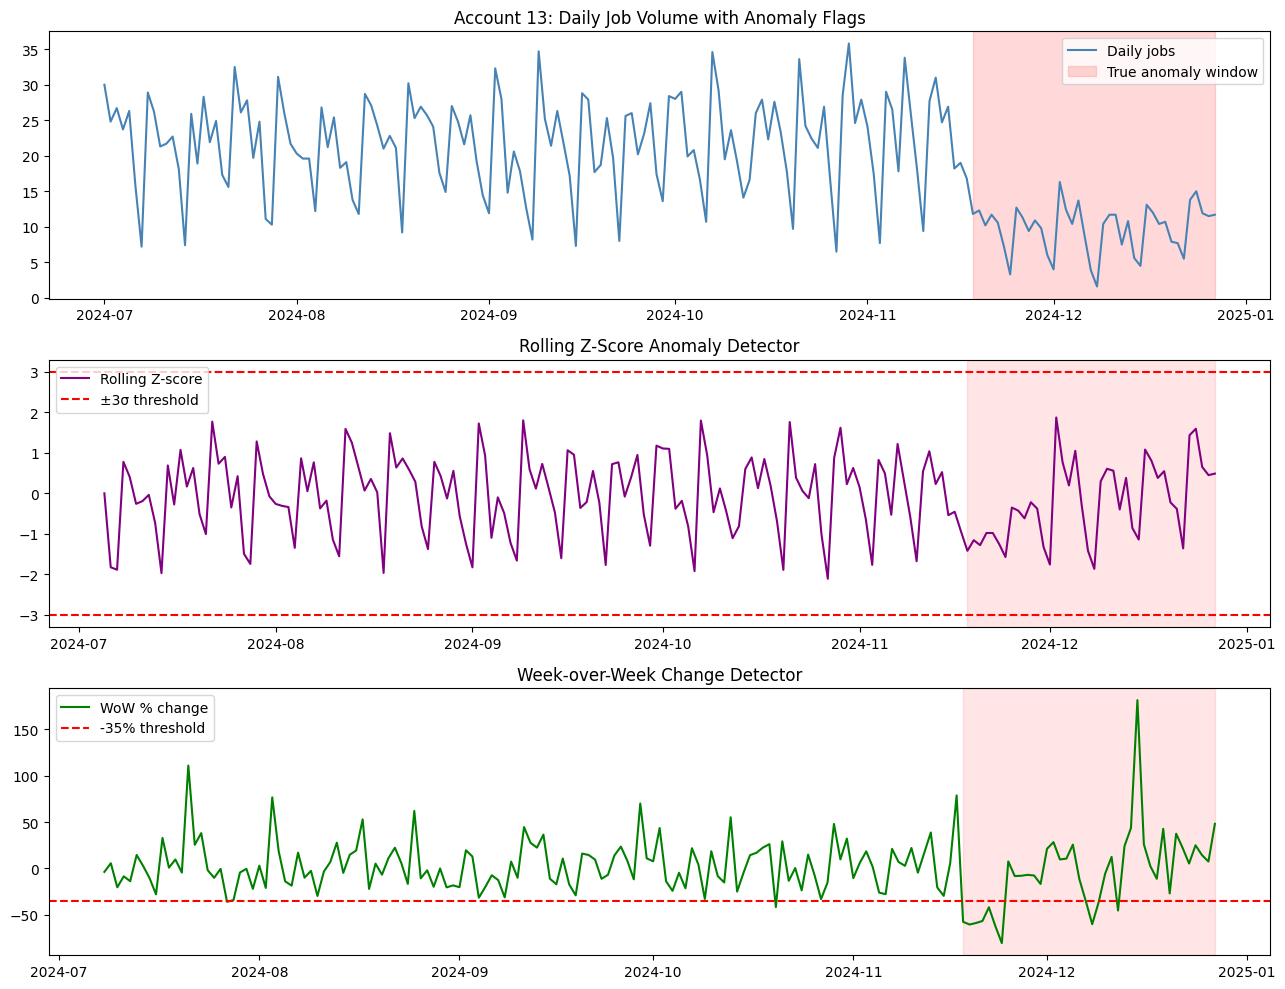

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def rolling_zscore_detector(series, window=14, threshold=3.0):
    """Flag points where value is >threshold std deviations from rolling mean."""
    roll_mean = series.rolling(window, min_periods=5).mean()
    roll_std  = series.rolling(window, min_periods=5).std()
    z_score   = (series - roll_mean) / (roll_std + 1e-9)
    return (z_score.abs() > threshold).astype(int), z_score

def wow_change_detector(series, threshold=0.35):
    """Flag points where week-over-week change exceeds threshold (35% drop)."""
    wow_change = (series - series.shift(7)) / (series.shift(7) + 1e-9)
    return (wow_change < -threshold).astype(int), wow_change

# Test on a specific account with a known anomaly
acct = sorted(anomaly_accounts)[0]
acct_data = all_data[all_data['account_id'] == acct].set_index('date')

zscore_flags, z_scores   = rolling_zscore_detector(acct_data['jobs'])
wow_flags,    wow_changes = wow_change_detector(acct_data['jobs'])
ground_truth = acct_data['has_anomaly'].astype(int)

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Raw metric
axes[0].plot(acct_data.index, acct_data['jobs'], color='steelblue', label='Daily jobs')
axes[0].axvspan(acct_data.index[140], acct_data.index[-1], alpha=0.15, color='red', label='True anomaly window')
for i, flag in enumerate(zscore_flags):
    if flag:
        axes[0].axvline(acct_data.index[i], color='orange', alpha=0.5, lw=0.8)
axes[0].set_title(f'Account {acct}: Daily Job Volume with Anomaly Flags'); axes[0].legend()

# Z-score
axes[1].plot(acct_data.index, z_scores, color='purple', label='Rolling Z-score')
axes[1].axhline(-3, color='red', linestyle='--', label='±3σ threshold')
axes[1].axhline(3, color='red', linestyle='--')
axes[1].axvspan(acct_data.index[140], acct_data.index[-1], alpha=0.1, color='red')
axes[1].set_title('Rolling Z-Score Anomaly Detector'); axes[1].legend()

# WoW change
axes[2].plot(acct_data.index, wow_changes * 100, color='green', label='WoW % change')
axes[2].axhline(-35, color='red', linestyle='--', label='-35% threshold')
axes[2].axvspan(acct_data.index[140], acct_data.index[-1], alpha=0.1, color='red')
axes[2].set_title('Week-over-Week Change Detector'); axes[2].legend()

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=100, bbox_inches='tight')
plt.show()


In [4]:
# ─── Isolation Forest: Multi-metric Anomaly Detection ────────────────────────
# Advantage: detects anomalies in the *combination* of metrics
# e.g., jobs down AND booking rate down AND cancel rate up simultaneously

def isolation_forest_detector(account_df, contamination=0.05):
    """
    Fit Isolation Forest on multi-dimensional metric space.
    Anomalies are points that are isolated early in the random tree partitioning.
    contamination: expected fraction of anomalies (hyperparameter to tune)
    """
    features = account_df[['jobs','revenue','booking_rate','cancel_rate']].copy()
    # Add rolling lag features
    for col in ['jobs','revenue']:
        features[f'{col}_wow'] = (features[col] - features[col].shift(7)) / (features[col].shift(7) + 1e-9)
    features = features.dropna()
    
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    
    iso = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
    iso.fit(X)
    
    scores  = iso.decision_function(X)  # lower = more anomalous
    is_anom = (iso.predict(X) == -1).astype(int)
    
    return pd.Series(is_anom, index=features.index), pd.Series(scores, index=features.index)

iso_flags, iso_scores = isolation_forest_detector(acct_data)
gt_aligned = ground_truth.reindex(iso_flags.index).fillna(0)

# Evaluate detection performance on this one account
detected    = iso_flags[gt_aligned == 1].sum()
total_anom  = (gt_aligned == 1).sum()
fp          = iso_flags[gt_aligned == 0].sum()
print(f"Isolation Forest on Account {acct}:")
print(f"  True anomaly days: {int(total_anom)}")
print(f"  Detected: {int(detected)} / {int(total_anom)}  ({detected/max(total_anom,1):.0%} recall)")
print(f"  False positives: {int(fp)}")

# Summary across all accounts
print("\n=== Cross-Account Detection Summary ===")
all_results = []
for acct_id in range(n_accounts):
    adf = all_data[all_data['account_id'] == acct_id].set_index('date')
    flags, _ = isolation_forest_detector(adf)
    gt = adf['has_anomaly'].reindex(flags.index).fillna(False).astype(int)
    all_results.append({
        'account_id':    acct_id,
        'has_anomaly':   acct_id in anomaly_accounts,
        'n_flags':       flags.sum(),
        'recall':        flags[gt==1].sum() / max(gt.sum(), 1)
    })

results_df = pd.DataFrame(all_results)
print(f"Accounts with ≥1 flag (anomaly accounts): "
      f"{results_df[results_df['has_anomaly']]['n_flags'].gt(0).sum()} / {len(anomaly_accounts)}")
print(f"Accounts with ≥1 flag (clean accounts): "
      f"{results_df[~results_df['has_anomaly']]['n_flags'].gt(0).sum()} / {n_accounts - len(anomaly_accounts)}")


Isolation Forest on Account 13:
  True anomaly days: 40
  Detected: 5 / 40  (12% recall)
  False positives: 4

=== Cross-Account Detection Summary ===


Accounts with ≥1 flag (anomaly accounts): 8 / 8
Accounts with ≥1 flag (clean accounts): 42 / 42


## Key Takeaways for Interview

1. **Rolling Z-score is your starting point** — interpretable, easy to tune threshold per metric
2. **Isolation Forest** handles multi-dimensional anomalies without labeled data
3. **False positive rate matters more than recall here** — if every alert is wrong, ops teams stop looking at them
4. **Account normalization**: compare each account against its own history (not cross-account), because contractors vary 10x in size
5. **Anomalies feed the churn model**: a sudden drop detected by the anomaly system is a strong churn feature
6. **Root cause attribution**: after detection, use SHAP to say "revenue is anomalously low because jobs are down, not because price dropped"
